In [ ]:
import numpy as np
print("test")
n = 6
pown = 2 ** n
VTnums = [1,1,2,2,4,6,10,16,30,52,94,172,316,586,1096, 2048, 3856, 7286, 13798, 26216, 49940, 95326, 182362, 349536, 671092, 1290556, 2485534, 4793492, 9256396, 17895736, 34636834, 67108864, 130150588, 252645136, 490853416]


def f7(seq):
    seen = set()
    seen_add = seen.add
    return [x for x in seq if not (x in seen or seen_add(x))]

def del4nat(binseq, n):
  seq = []
  for i in range(0, n):
    up  = binseq // (2 ** (i+1))
    low = binseq % (2 ** i)
    join = up * (2 ** i ) + low
    seq.append(join)
  return f7(seq)

def del4natbin(binseq, n):
  seq = []
  for i in range(0, n):
    up  = binseq // (2 ** (i+1))
    low = binseq % (2 ** i)
    join = up * (2 ** i ) + low
    join = bin(join)
    seq.append(join)
  return f7(seq)

def ins4nat(binseq,n):
  SET = set()
  for i in range(0,n):
    up  = binseq // (2 ** (i))
    low = binseq % (2 ** i)
    ins1 = up*2 + 1
    ins0 = up*2
    ins1 = ins1*(2**i) + low
    ins0 = ins0*(2**i) + low
    SET.add(ins1)
    SET.add(ins0)
  return SET

for i in range(10):
    print(del4nat(341,i))
for i in range(10):
    print(del4natbin(341,i))


test
[]
[170]
[170, 171]
[170, 171, 169]
[170, 171, 169, 173]
[170, 171, 169, 173, 165]
[170, 171, 169, 173, 165, 181]
[170, 171, 169, 173, 165, 181, 149]
[170, 171, 169, 173, 165, 181, 149, 213]
[170, 171, 169, 173, 165, 181, 149, 213, 85]
[]
['0b10101010']
['0b10101010', '0b10101011']
['0b10101010', '0b10101011', '0b10101001']
['0b10101010', '0b10101011', '0b10101001', '0b10101101']
['0b10101010', '0b10101011', '0b10101001', '0b10101101', '0b10100101']
['0b10101010', '0b10101011', '0b10101001', '0b10101101', '0b10100101', '0b10110101']
['0b10101010', '0b10101011', '0b10101001', '0b10101101', '0b10100101', '0b10110101', '0b10010101']
['0b10101010', '0b10101011', '0b10101001', '0b10101101', '0b10100101', '0b10110101', '0b10010101', '0b11010101']
['0b10101010', '0b10101011', '0b10101001', '0b10101101', '0b10100101', '0b10110101', '0b10010101', '0b11010101', '0b1010101']


In [ ]:
from math import ceil, log2
def check_sum(i):
    if i == 0:
        return 0
    bin_len = ceil(log2(i))+1
    sum = 0
    for j in range(bin_len):
        sum += (j+1)*((i//(2**j))%2)
    return sum
def rev_sum(i,n):
    if i == 0:
        return 0
    sum = 0
    for j in range(n):
        sum += (j+1)*((i//(2**(n-j-1)))%2)
    return sum
#print(check_sum(11))
def VT0_code(n):
    pown = 2**n
    listVT = []
    for i in range(pown):
        if check_sum(i)%(n+1) == 0:
            listVT.append(i)
    return listVT
def VTa_code(n,a):
    pown = 2**n
    listVT = []
    for i in range(pown):
        if check_sum(i)%(n+1) == a:
            listVT.append(i)
    return listVT
cards = []
for i in range(14):
    cards.append(len(VT0_code(i)))
print(cards)

for i in range(10):
    print(VT0_code(i))

[1, 1, 2, 2, 4, 6, 10, 16, 30, 52, 94, 172, 316, 586]
[0]
[0]
[0, 3]
[0, 5]
[0, 6, 9, 15]
[0, 7, 10, 17, 27, 28]
[0, 11, 12, 18, 30, 33, 45, 51, 52, 63]
[0, 13, 19, 20, 34, 47, 54, 57, 65, 78, 85, 88, 99, 100, 119, 122]
[0, 14, 21, 24, 35, 36, 59, 60, 66, 87, 90, 102, 105, 112, 126, 129, 143, 150, 153, 165, 168, 189, 195, 196, 219, 220, 231, 234, 241, 255]
[0, 15, 22, 25, 37, 40, 62, 67, 68, 93, 107, 108, 114, 130, 155, 156, 167, 170, 177, 198, 201, 208, 223, 238, 245, 248, 257, 279, 282, 294, 297, 304, 319, 325, 328, 350, 365, 371, 372, 387, 388, 413, 427, 428, 434, 455, 458, 465, 480, 495, 502, 505]


In [ ]:
n=6

bin_string_dict = {}
for m in range(15):
    bin_strings = []
    for x in range(2**m):
        bin_strings.append(bin(x)[2:].zfill(m))
    bin_string_dict[m] = bin_strings

def ham_weight(x):
    count = 0
    for i in range(len(x)):
        if int(x[i]) == 1:
            count += 1
    return count

def wt_int(x):
    count = 0
    for i in range(n+1):
        count += (x//(2**i))%2
    return count

def runs_int(x):
    count = 1
    for i in range(n-1):
        a = (x//(2**i))%2
        b = (x//(2**(i+1)))%2
        if a != b:
             count += 1
    return count



In [ ]:
from itertools import chain, combinations
import numpy as np

def powerset(iterable):
    "powerset([1,2,3]) --> () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

n = 4

def list2density(liss):
  code_list = list(range(2**(n-1)))
  count = 0
  for i in liss:
    for d in del4nat(i,n):
      try:
        code_list.remove(d)
      except ValueError:
        count += 1
  return count

combos = list(combinations(range(2**n),VTnums[n]))
for c in combos:
    c = list(c)
    if list2density(c) == 0:
        print(c)
        #print([check_sum(a) for a in c])

[0, 3, 10, 15]
[0, 3, 12, 15]
[0, 5, 12, 15]
[0, 6, 9, 15]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]


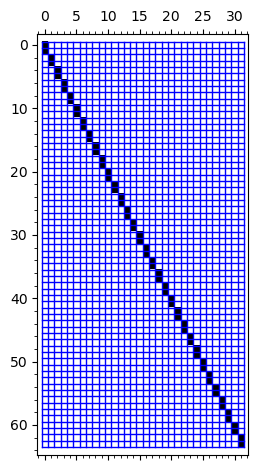

-------------1


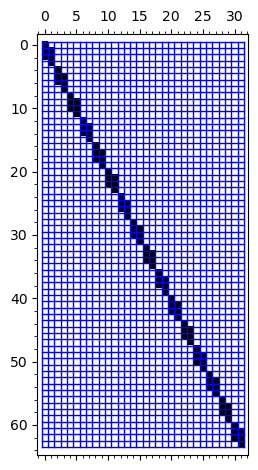

-------------2


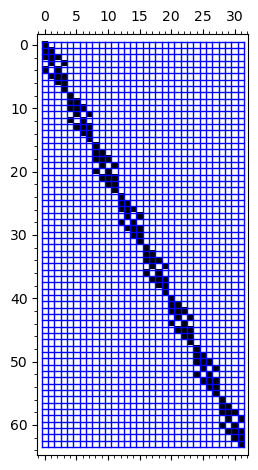

-------------3


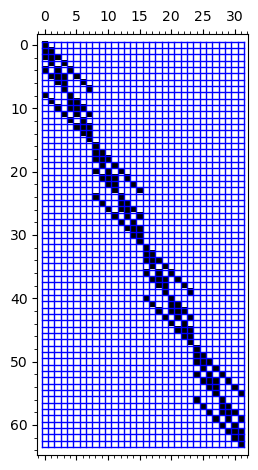

-------------4


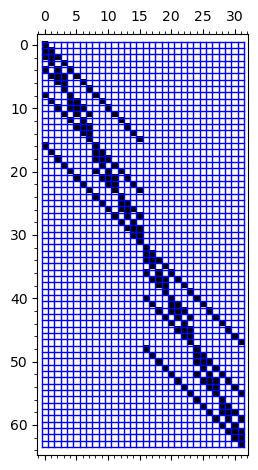

-------------5


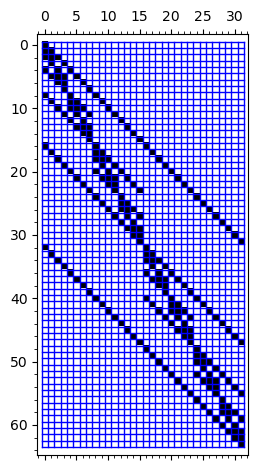

-------------6


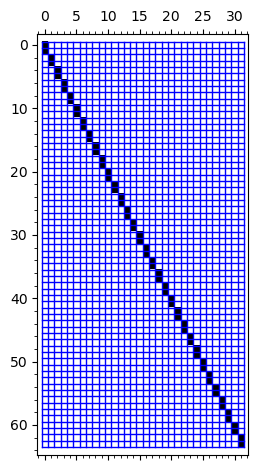

B-------------------0


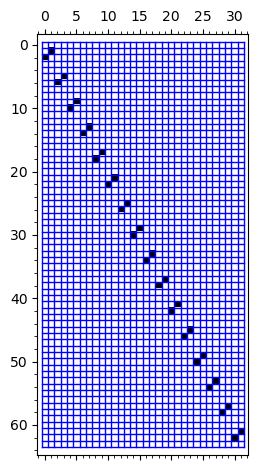

B-------------------1


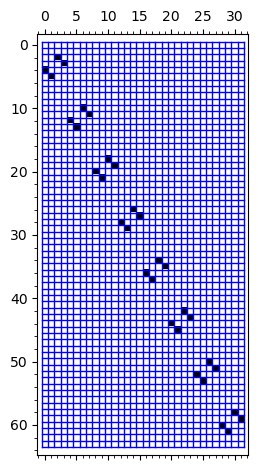

B-------------------2


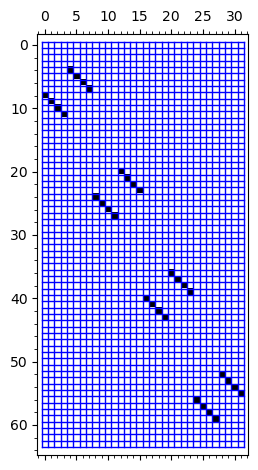

B-------------------3


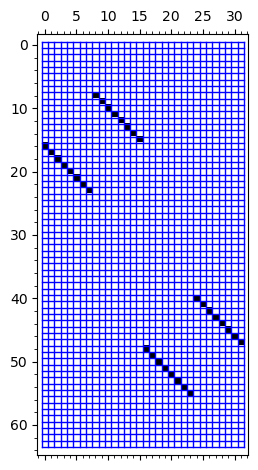

B-------------------4


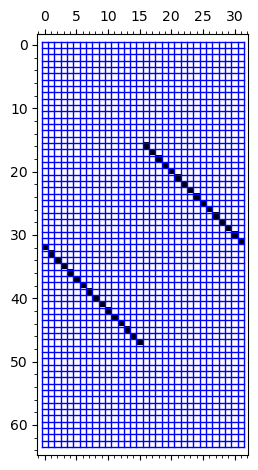

B-------------------5


In [ ]:
n = 6
r = list(range(2**n))
v = list(range(2**(n-1)))
m = []
A = []
B = []

def wt_int(x):
    count = 0
    for i in range(n+1):
        count += (x//(2**i))%2
    return count

def VTclass(v):
    c = check_sum(v)%(n+1)
    return c

a=1
def VTclassN(v):
    c = check_sum(v)%(a+1)
    return c

def VTinsertion(d):
    inss = ins4nat(d,n)
    for v in inss:
        if check_sum(v)%(n+1) == 0:
            return v

def min_del(w):
    dels = del4nat(w,n)
    m = min(dels)
    return m

#r.sort(key = VTclass)
#r.sort(key = VTclassN)
#r.sort(key = wt_int)
#r.sort(key = runs_int)
#r.sort(key = min_del)
#v.sort(key = VTinsertion)
order = sorted(list(range(len(r))), key=lambda i: r[i])
l1 = [r[i] for i in order]
inverse_order = sorted(order, key=lambda i: order[i])
l0_again = [l1[i] for i in inverse_order]
print(l0_again)

for k in range(1,n+1):
    m = []
    for i in range(len(r)):
        d = set(del4nat(r[i],k))
        row = []
        for j in range(len(v)):
            size = 0
            if v[j] in d:
                size = 1
            row.append(size)

        m.append(row)
        
    m = matrix(m)
    A.append(m)
    matrix_plot(m,subdivisions = True, subdivision_boundaries = [list(range(2**n+1)),list(range(2**(n-1)+1))]).show()
    print('-------------'+str(k))
B.append(A[0])
for k in range(1,n):
    B.append(A[k] - A[k-1])
for k in range(n):
    matrix_plot(B[k],subdivisions = True, subdivision_boundaries = [list(range(2**n+1)),list(range(2**(n-1)+1))]).show()
    print('B-------------------'+str(k))

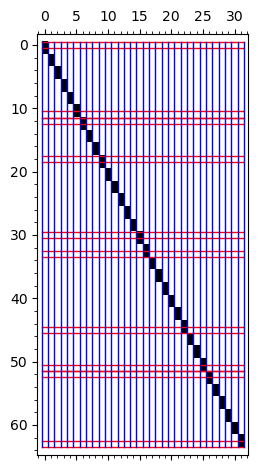

A-------------------0


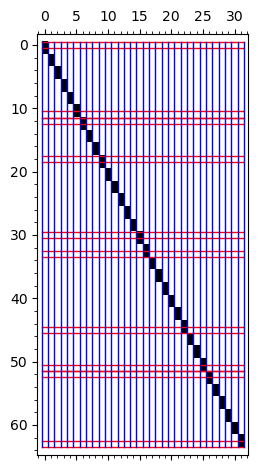

B-------------------0


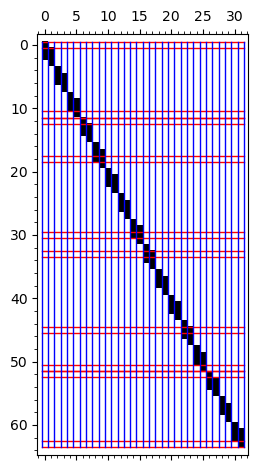

A-------------------1


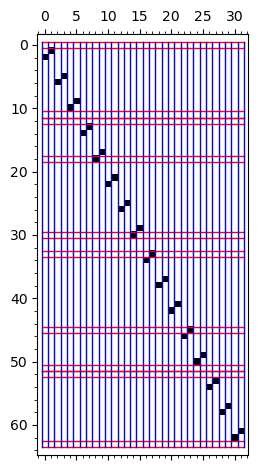

B-------------------1


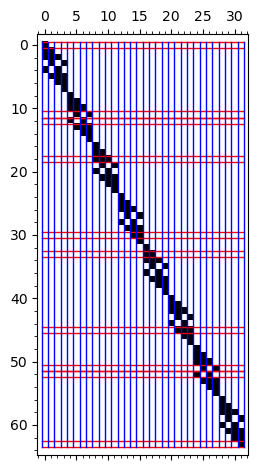

A-------------------2


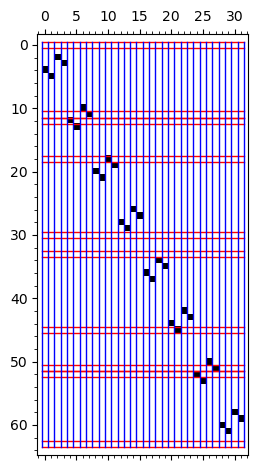

B-------------------2


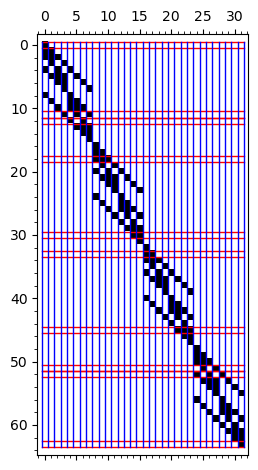

A-------------------3


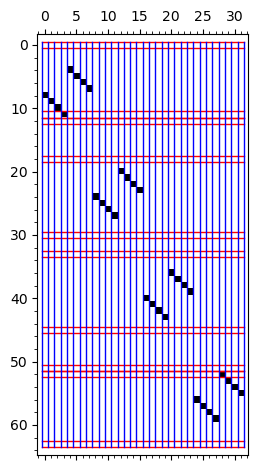

B-------------------3


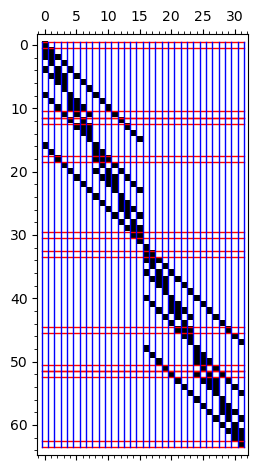

A-------------------4


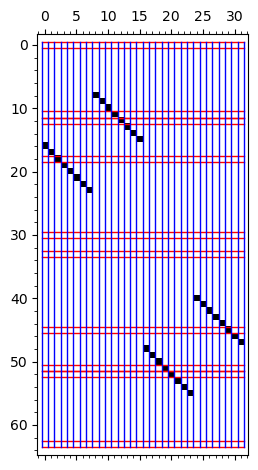

B-------------------4


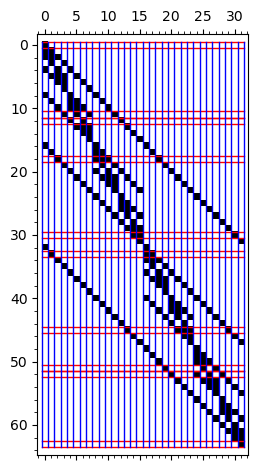

A-------------------5


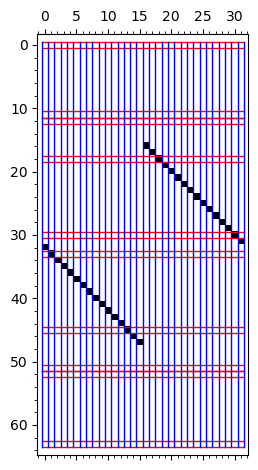

B-------------------5


In [ ]:
red_bars = VT0_code(n)
for k in range(n):
    matrix_plot(A[k],subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [[order[c] for c in red_bars] + [order[c]+1 for c in red_bars],list(range(2**(n-1)+1))]).show()
    print('A-------------------'+str(k))
    matrix_plot(B[k],subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [[order[c] for c in red_bars] + [order[c]+1 for c in red_bars],list(range(2**(n-1)+1))]).show()
    print('B-------------------'+str(k))

In [ ]:
def differer(input):
#inputs list of sets outputs half as many sets from differences
    output = []
    l = len(list(input))
    c=0
    while c < l:
        d = set(input[c+1]).symmetric_difference(set(input[c]))
        output.append(d)
        c += 2
    return output

groups = dict()

for m in range(n):
    groups[m] = dict()
    for l in range(2**(n-1)):
        groups[m][l] = []
        for k in range(2**(n)):
            if A[m][k][l] == 1:
                groups[m][l].append(k)
        print(groups[m][l])
sym = 1
diffs = dict()
for m in range(1,3):
    diffs[m] = []
    c = 0
    while c < 16:
        d = set(groups[m][c+1]).symmetric_difference(set(groups[m][c]))
        diffs[m].append(d)
        c += 2
    print(diffs[m])
diffs[2] = differer(diffs[2])
print(diffs)

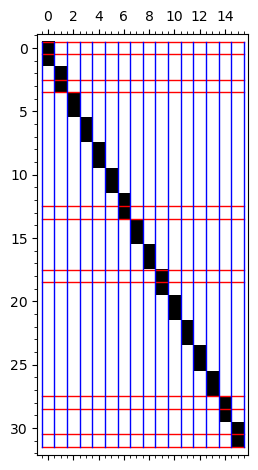

A-------------------0


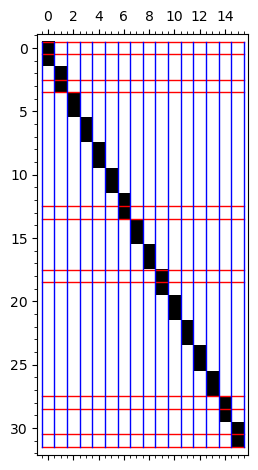

B-------------------0


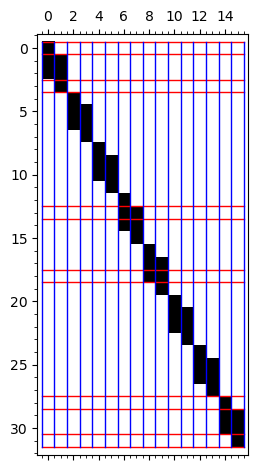

A-------------------1


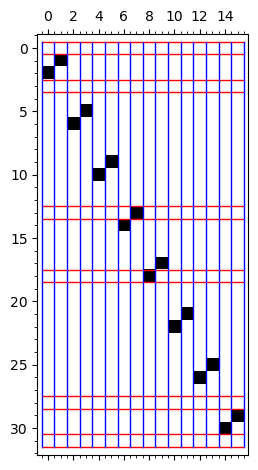

B-------------------1


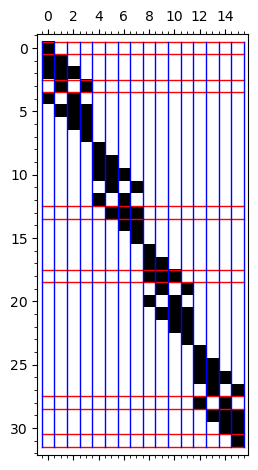

A-------------------2


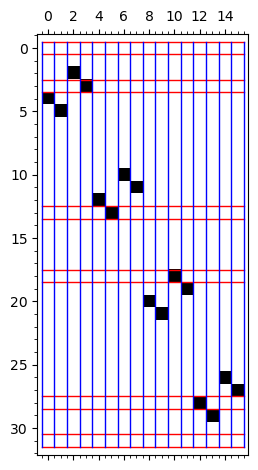

B-------------------2


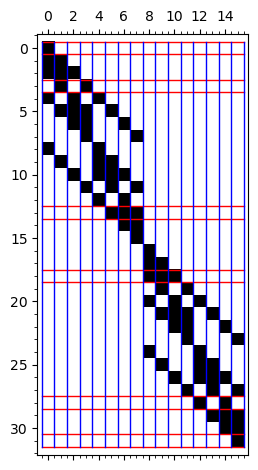

A-------------------3


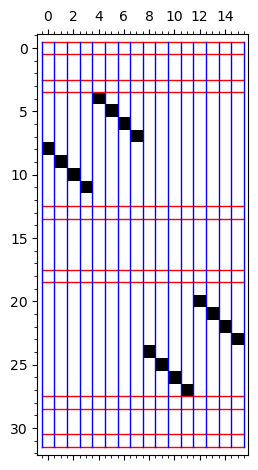

B-------------------3


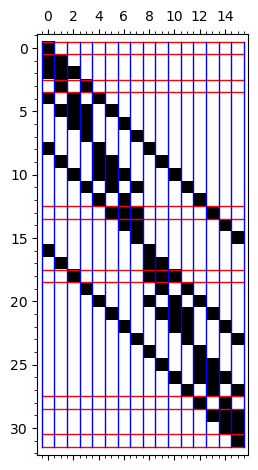

A-------------------4


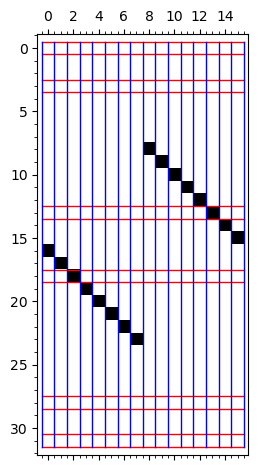

B-------------------4


In [ ]:
sym5 = [0, 7, 9, 22, 24, 31] 
sym5 = [0, 3, 13, 18, 28, 31]

for k in range(n):
    matrix_plot(A[k],subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [sym5 + [c+1 for c in sym5],list(range(2**(n-1)+1))]).show()
    print('A-------------------'+str(k))
    matrix_plot(B[k],subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [sym5 + [c+1 for c in sym5],list(range(2**(n-1)+1))]).show()
    print('B-------------------'+str(k))

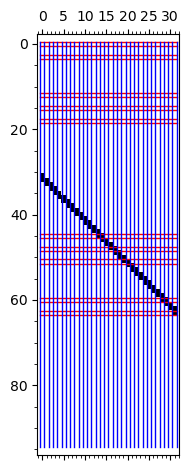

-------------1


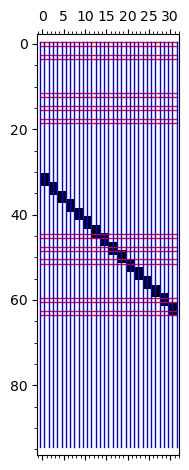

-------------2


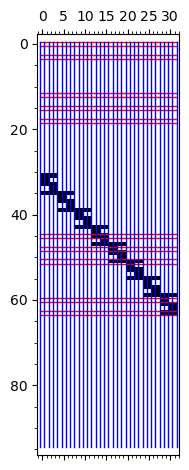

-------------3


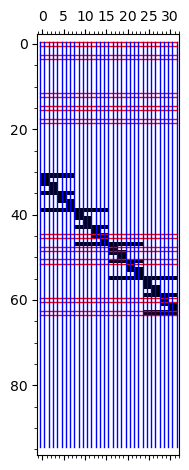

-------------4


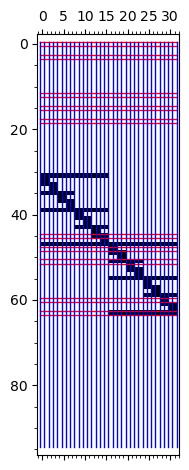

-------------5


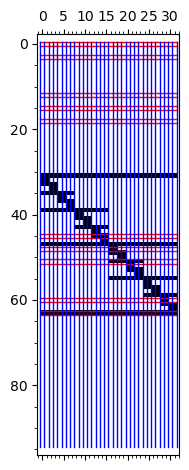

-------------6


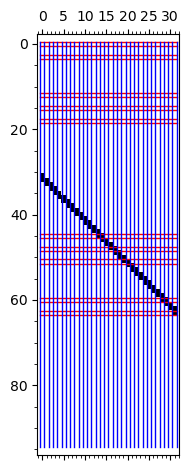

B-------------------0


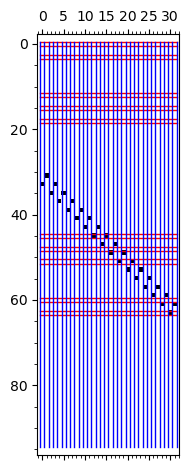

B-------------------1


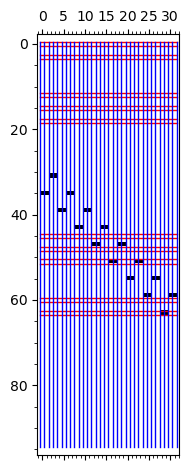

B-------------------2


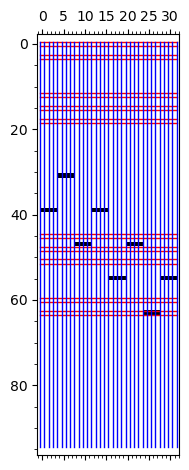

B-------------------3


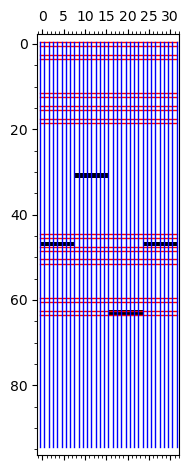

B-------------------4


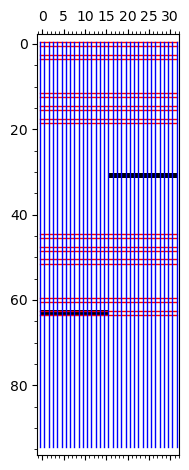

B-------------------5


In [ ]:
n = 6
sym6 = [0, 3, 12, 15, 63, 60, 51, 48, 45, 18]
sym7 = [0, 3, 12, 15, 18, 43, 58, 69, 84, 109, 112, 115, 124, 127, 49, 78]
r = list(range(2**n))
v = list(range(2**(n-1)))
m = []
A = []
B = []
for k in range(1,n+1):
    m = []
    for i in range(len(r)):
        d = set(del4nat(r[i],k))
        row = []
        for j in range(len(v)):
            size = 0
            if v[j] in d:
                size = 1
            row.append(size)
        m.append(row)
        
    m = matrix(m)
    m = slantize(m)
    A.append(m)
    matrix_plot(m,subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [sym6 + [c+1 for c in sym6],list(range(2**(n-1)+1))]).show()
    print('-------------'+str(k))
B.append(A[0])
for k in range(1,n):
    B.append(A[k] - A[k-1])

for k in range(n):
    matrix_plot(B[k],subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [sym6 + [c+1 for c in sym6],list(range(2**(n-1)+1))]).show()
    print('B-------------------'+str(k))

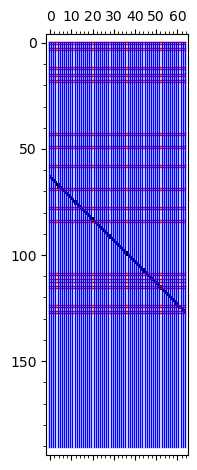

-------------1


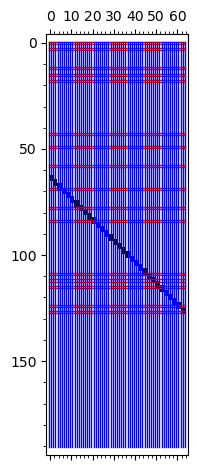

-------------2


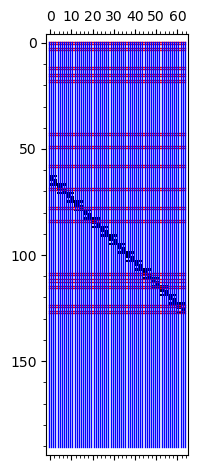

-------------3


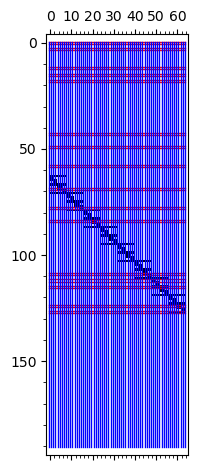

-------------4


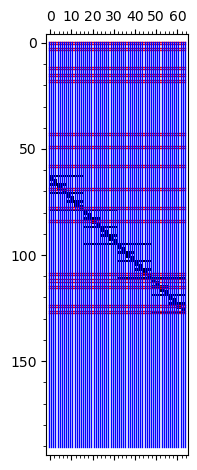

-------------5


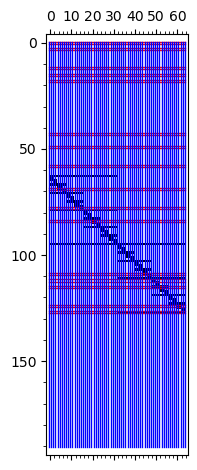

-------------6


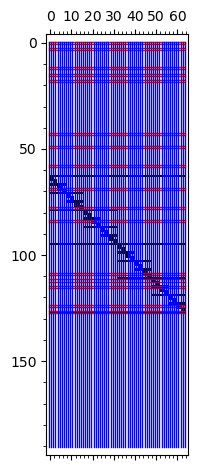

-------------7


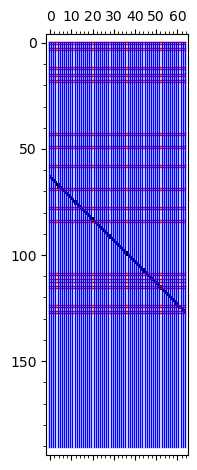

B-------------------0


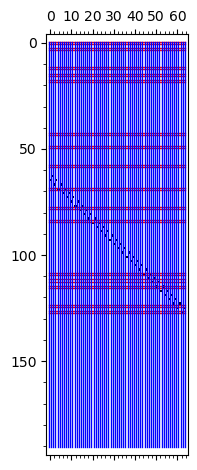

B-------------------1


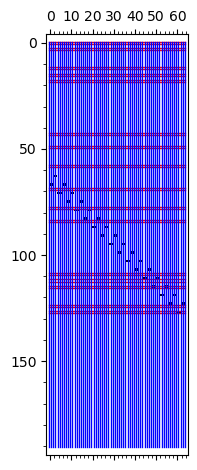

B-------------------2


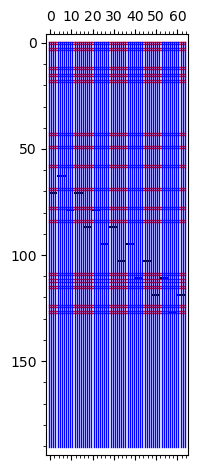

B-------------------3


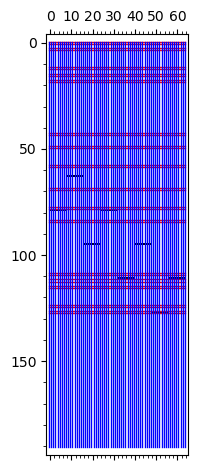

B-------------------4


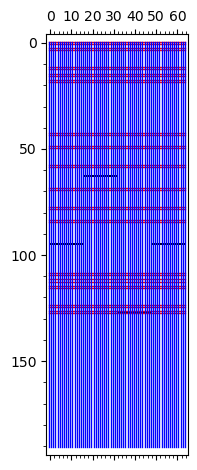

B-------------------5


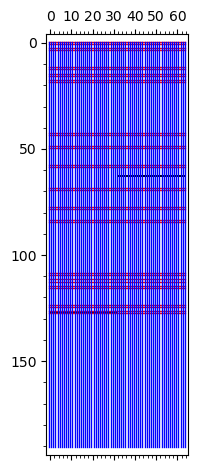

B-------------------6


In [ ]:
n = 7
sym6 = [0, 3, 12, 15, 63, 60, 51, 48, 45, 18]
sym7 = [0, 3, 12, 15, 18, 43, 49, 58, 69, 78, 84, 109, 112, 115, 124, 127]
r = list(range(2**n))
v = list(range(2**(n-1)))
m = []
A = []
B = []
for k in range(1,n+1):
    m = []
    for i in range(len(r)):
        d = set(del4nat(r[i],k))
        row = []
        for j in range(len(v)):
            size = 0
            if v[j] in d:
                size = 1
            row.append(size)
        m.append(row)
        
    m = matrix(m)
    m=slantize(m)
    A.append(m)
    matrix_plot(m,subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [sym7 + [c+1 for c in sym7],list(range(2**(n-1)+1))]).show()
    print('-------------'+str(k))
B.append(A[0])
for k in range(1,n):
    B.append(A[k] - A[k-1])

for k in range(n):
    matrix_plot(B[k],subdivisions = True, subdivision_style = [dict(color = 'red'),dict(color = 'blue')], subdivision_boundaries = [sym7 + [c+1 for c in sym7],list(range(2**(n-1)+1))]).show()
    print('B-------------------'+str(k))

In [ ]:
m = [[0.0,0.1,0.2],[1.0,1.1,1.2],[2.0,2.1,2.2],[3.0,3.1,3.2],[4.0,4.1,4.2]]
m = matrix(m)
print(m)
print(m.nrows())
print(np.array(m)[2][1])

def slantize(matrixin):
#converts an m by n matrix into a (m+n-1) by n, diags to rows
    matout = []
    m = matrixin.nrows()
    n = matrixin.ncols()
    matlist = np.array(matrixin)
    for mu in range(n+m-1):
        addrow = []
        for nu in range(n):
            if mu-n+nu+1>=0:
                try:
                    addrow.append(matlist[mu-n+nu+1][nu])
                except:
                    addrow.append(0)
            else:
                addrow.append(0)
        matout.append(addrow)
    result = matrix(matout)
    return result

print(slantize(m))
        

[0.000000000000000 0.100000000000000 0.200000000000000]
[ 1.00000000000000  1.10000000000000  1.20000000000000]
[ 2.00000000000000  2.10000000000000  2.20000000000000]
[ 3.00000000000000  3.10000000000000  3.20000000000000]
[ 4.00000000000000  4.10000000000000  4.20000000000000]
5
2.1
[0.0 0.0 0.2]
[0.0 0.1 1.2]
[0.0 1.1 2.2]
[1.0 2.1 3.2]
[2.0 3.1 4.2]
[3.0 4.1 0.0]
[4.0 0.0 0.0]


In [ ]:
import sympy as sp

def VTsummand(d,a,n):
    pd = euler_phi(d)
    g = gcd(a,d)
    q = Integer(d/g)
    mu = sp.ntheory.mobius(q)
    pq = euler_phi(q)
    t = 2**((n+1)/d)
    out = Integer(pd*mu/pq*t)
    return out

def VTsize(a,n):
    f = 1/(2*n+2)
    l = []
    for d in range(1,n+2):
        if Integer(d).divides(n+1) and d%2 == 1:
            l.append(VTsummand(d,a,n))
    out = int(sum(l)*f)
    return out

s=0
for i in range(1,33):
    print('n is',i-1,end = ' ')
    print('sum is',s)
    s=0
    for j in range(i+1):
        print(VTsize(j,i),end = ' ')
        s += VTsize(j,i)


n is 0 sum is 0
1 1 n is 1 sum is 2
2 1 1 n is 2 sum is 4
2 2 2 2 n is 3 sum is 8
4 3 3 3 3 n is 4 sum is 16
6 5 5 6 5 5 n is 5 sum is 32
10 9 9 9 9 9 9 n is 6 sum is 64
16 16 16 16 16 16 16 16 n is 7 sum is 128
30 28 28 29 28 28 29 28 28 n is 8 sum is 256
52 51 51 51 51 52 51 51 51 51 n is 9 sum is 512
94 93 93 93 93 93 93 93 93 93 93 n is 10 sum is 1024
172 170 170 172 170 170 172 170 170 172 170 170 n is 11 sum is 2048
316 315 315 315 315 315 315 315 315 315 315 315 315 n is 12 sum is 4096
586 585 585 585 585 585 585 586 585 585 585 585 585 585 n is 13 sum is 8192
1096 1091 1091 1094 1091 1092 1094 1091 1091 1094 1092 1091 1094 1091 1091 n is 14 sum is 16384
2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 2048 n is 15 sum is 32768
3856 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 3855 n is 16 sum is 65536
7286 7280 7280 7285 7280 7280 7285 7280 7280 7286 7280 7280 7285 7280 7280 7285 7280 7280 n is 17 sum is 131072
13798 13797

In [ ]:
for i in range(2**10):
    il = []
    for c in range(10):
        il.append(check_sum(i)%(c+1))
    print(i,il)

0 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1 [0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
2 [0, 0, 2, 2, 2, 2, 2, 2, 2, 2]
3 [0, 1, 0, 3, 3, 3, 3, 3, 3, 3]
4 [0, 1, 0, 3, 3, 3, 3, 3, 3, 3]
5 [0, 0, 1, 0, 4, 4, 4, 4, 4, 4]
6 [0, 1, 2, 1, 0, 5, 5, 5, 5, 5]
7 [0, 0, 0, 2, 1, 0, 6, 6, 6, 6]
8 [0, 0, 1, 0, 4, 4, 4, 4, 4, 4]
9 [0, 1, 2, 1, 0, 5, 5, 5, 5, 5]
10 [0, 0, 0, 2, 1, 0, 6, 6, 6, 6]
11 [0, 1, 1, 3, 2, 1, 0, 7, 7, 7]
12 [0, 1, 1, 3, 2, 1, 0, 7, 7, 7]
13 [0, 0, 2, 0, 3, 2, 1, 0, 8, 8]
14 [0, 1, 0, 1, 4, 3, 2, 1, 0, 9]
15 [0, 0, 1, 2, 0, 4, 3, 2, 1, 0]
16 [0, 1, 2, 1, 0, 5, 5, 5, 5, 5]
17 [0, 0, 0, 2, 1, 0, 6, 6, 6, 6]
18 [0, 1, 1, 3, 2, 1, 0, 7, 7, 7]
19 [0, 0, 2, 0, 3, 2, 1, 0, 8, 8]
20 [0, 0, 2, 0, 3, 2, 1, 0, 8, 8]
21 [0, 1, 0, 1, 4, 3, 2, 1, 0, 9]
22 [0, 0, 1, 2, 0, 4, 3, 2, 1, 0]
23 [0, 1, 2, 3, 1, 5, 4, 3, 2, 1]
24 [0, 1, 0, 1, 4, 3, 2, 1, 0, 9]
25 [0, 0, 1, 2, 0, 4, 3, 2, 1, 0]
26 [0, 1, 2, 3, 1, 5, 4, 3, 2, 1]
27 [0, 0, 0, 0, 2, 0, 5, 4, 3, 2]
28 [0, 0, 0, 0, 2, 0, 5, 4, 3, 2]
29 [0, 1, 1, 1, 3, 1, 6,

656 [0, 1, 2, 3, 3, 5, 2, 7, 5, 3]
657 [0, 0, 0, 0, 4, 0, 3, 0, 6, 4]
658 [0, 1, 1, 1, 0, 1, 4, 1, 7, 5]
659 [0, 0, 2, 2, 1, 2, 5, 2, 8, 6]
660 [0, 0, 2, 2, 1, 2, 5, 2, 8, 6]
661 [0, 1, 0, 3, 2, 3, 6, 3, 0, 7]
662 [0, 0, 1, 0, 3, 4, 0, 4, 1, 8]
663 [0, 1, 2, 1, 4, 5, 1, 5, 2, 9]
664 [0, 1, 0, 3, 2, 3, 6, 3, 0, 7]
665 [0, 0, 1, 0, 3, 4, 0, 4, 1, 8]
666 [0, 1, 2, 1, 4, 5, 1, 5, 2, 9]
667 [0, 0, 0, 2, 0, 0, 2, 6, 3, 0]
668 [0, 0, 0, 2, 0, 0, 2, 6, 3, 0]
669 [0, 1, 1, 3, 1, 1, 3, 7, 4, 1]
670 [0, 0, 2, 0, 2, 2, 4, 0, 5, 2]
671 [0, 1, 0, 1, 3, 3, 5, 1, 6, 3]
672 [0, 0, 0, 0, 4, 0, 3, 0, 6, 4]
673 [0, 1, 1, 1, 0, 1, 4, 1, 7, 5]
674 [0, 0, 2, 2, 1, 2, 5, 2, 8, 6]
675 [0, 1, 0, 3, 2, 3, 6, 3, 0, 7]
676 [0, 1, 0, 3, 2, 3, 6, 3, 0, 7]
677 [0, 0, 1, 0, 3, 4, 0, 4, 1, 8]
678 [0, 1, 2, 1, 4, 5, 1, 5, 2, 9]
679 [0, 0, 0, 2, 0, 0, 2, 6, 3, 0]
680 [0, 0, 1, 0, 3, 4, 0, 4, 1, 8]
681 [0, 1, 2, 1, 4, 5, 1, 5, 2, 9]
682 [0, 0, 0, 2, 0, 0, 2, 6, 3, 0]
683 [0, 1, 1, 3, 1, 1, 3, 7, 4, 1]
684 [0, 1, 1, 3, 1, 

In [ ]:
for n in range(1,6):
    print('all optimal codes for n = ',n)
    combos = list(combinations(range(2**n),VTnums[n]))
    for c in combos:
        c = list(c)
        if list2density(c) == 0:
            print(c)
        #print([check_sum(a) for a in c])

all optimal codes for n =  1
[0]
[1]
all optimal codes for n =  2
[0, 3]
all optimal codes for n =  3
[0, 3]
[0, 5]
[0, 6]
[0, 7]
[1, 6]
[1, 7]
[2, 7]
[3, 4]
[4, 7]
all optimal codes for n =  4
[0, 3, 10, 15]
[0, 3, 12, 15]
[0, 5, 12, 15]
[0, 6, 9, 15]
all optimal codes for n =  5
[0, 3, 13, 18, 28, 31]
[0, 3, 14, 21, 24, 31]
[0, 7, 9, 22, 24, 31]
[0, 7, 10, 17, 27, 28]
[0, 7, 10, 17, 28, 31]
[3, 4, 14, 21, 24, 31]


In [ ]:
print('all symmetric optimal codes for n = 6 from Mana')
print('[[0, 3, 12, 15, 18, 45, 48, 51, 60, 63] \n [0, 7, 12, 18, 30, 33, 45, 51, 56, 63] \n [0, 11, 12, 18, 30, 33, 45, 51, 52, 63]]')
print('all optimal codes for 6 from Mana')
print('[0, 3, 12, 15, 18, 45, 48, 51, 60, 63]\n [0, 3, 12, 15, 21, 34, 46, 51, 52, 63]\n [0, 3, 12, 15, 21, 34, 46, 51, 56, 63]\n [0, 7, 12, 17, 29, 42, 48, 51, 60, 63]\n [0, 7, 12, 18, 30, 33, 45, 51, 52, 63]\n [0, 7, 12, 18, 30, 33, 45, 51, 56, 63]\n [0, 11, 12, 17, 29, 42, 48, 51, 60, 63]\n [0, 11, 12, 18, 30, 33, 45, 51, 52, 63]\n [0, 11, 12, 18, 30, 33, 45, 51, 56, 63]]')

all symmetric optimal codes for n = 6 from Mana
[[0, 3, 12, 15, 18, 45, 48, 51, 60, 63] 
 [0, 7, 12, 18, 30, 33, 45, 51, 56, 63] 
 [0, 11, 12, 18, 30, 33, 45, 51, 52, 63]]
all optimal codes for 6 from Mana
[0, 3, 12, 15, 18, 45, 48, 51, 60, 63]
 [0, 3, 12, 15, 21, 34, 46, 51, 52, 63]
 [0, 3, 12, 15, 21, 34, 46, 51, 56, 63]
 [0, 7, 12, 17, 29, 42, 48, 51, 60, 63]
 [0, 7, 12, 18, 30, 33, 45, 51, 52, 63]
 [0, 7, 12, 18, 30, 33, 45, 51, 56, 63]
 [0, 11, 12, 17, 29, 42, 48, 51, 60, 63]
 [0, 11, 12, 18, 30, 33, 45, 51, 52, 63]
 [0, 11, 12, 18, 30, 33, 45, 51, 56, 63]]


In [ ]:
print('all symmetric optimal codes for n = 7 from Mana:')
print('[0, 3, 12, 15, 18, 43, 49, 58, 69, 78, 84, 109, 112, 115, 124, 127]\n',
'[0, 3, 12, 18, 31, 43, 49, 58, 69, 78, 84, 96, 109, 115, 124, 127]\n',
'[0, 3, 12, 21, 30, 34, 55, 56, 71, 72, 93, 97, 106, 115, 124, 127]\n',
'[0, 3, 13, 18, 31, 46, 51, 52, 75, 76, 81, 96, 109, 114, 124, 127]\n',
'[0, 3, 15, 21, 24, 36, 46, 57, 70, 81, 91, 103, 106, 112, 124, 127]\n',
'[0, 3, 15, 21, 28, 38, 40, 59, 68, 87, 89, 99, 106, 112, 124, 127]\n',
'[0, 3, 15, 21, 28, 38, 40, 61, 66, 87, 89, 99, 106, 112, 124, 127]\n',
'[0, 3, 15, 22, 25, 37, 40, 59, 68, 87, 90, 102, 105, 112, 124, 127]\n',
'[0, 3, 15, 22, 25, 37, 40, 61, 66, 87, 90, 102, 105, 112, 124, 127]\n',
'[0, 3, 21, 24, 31, 36, 46, 57, 70, 81, 91, 96, 103, 106, 124, 127]\n',
'[0, 3, 22, 25, 31, 36, 39, 58, 69, 88, 91, 96, 102, 105, 124, 127]\n',
'[0, 7, 9, 27, 28, 38, 40, 61, 66, 87, 89, 99, 100, 118, 120, 127]\n',
'[0, 7, 10, 17, 28, 31, 43, 50, 77, 84, 96, 99, 110, 117, 120, 127]\n',
'[0, 7, 10, 17, 30, 45, 51, 52, 75, 76, 82, 97, 110, 117, 120, 127]\n',
'[0, 7, 10, 17, 31, 45, 51, 52, 75, 76, 82, 96, 110, 117, 120, 127]\n',
'[0, 7, 10, 28, 31, 33, 43, 50, 77, 84, 94, 96, 99, 117, 120, 127]\n',
'[0, 7, 10, 31, 33, 45, 51, 52, 75, 76, 82, 94, 96, 117, 120, 127]\n',
'[0, 7, 12, 18, 31, 43, 49, 58, 69, 78, 84, 96, 109, 115, 120, 127]\n',
'[0, 7, 21, 24, 31, 36, 46, 57, 70, 81, 91, 96, 103, 106, 120, 127]\n',
'[0, 9, 14, 24, 31, 34, 43, 60, 67, 84, 93, 96, 103, 113, 118, 127]\n',
'[0, 10, 15, 19, 28, 33, 50, 55, 72, 77, 94, 99, 108, 112, 117, 127]\n',
'[0, 15, 22, 25, 37, 40, 59, 60, 67, 68, 87, 90, 102, 105, 112, 127]')

all symmetric optimal codes for n = 7 from Mana:
[0, 3, 12, 15, 18, 43, 49, 58, 69, 78, 84, 109, 112, 115, 124, 127]
 [0, 3, 12, 18, 31, 43, 49, 58, 69, 78, 84, 96, 109, 115, 124, 127]
 [0, 3, 12, 21, 30, 34, 55, 56, 71, 72, 93, 97, 106, 115, 124, 127]
 [0, 3, 13, 18, 31, 46, 51, 52, 75, 76, 81, 96, 109, 114, 124, 127]
 [0, 3, 15, 21, 24, 36, 46, 57, 70, 81, 91, 103, 106, 112, 124, 127]
 [0, 3, 15, 21, 28, 38, 40, 59, 68, 87, 89, 99, 106, 112, 124, 127]
 [0, 3, 15, 21, 28, 38, 40, 61, 66, 87, 89, 99, 106, 112, 124, 127]
 [0, 3, 15, 22, 25, 37, 40, 59, 68, 87, 90, 102, 105, 112, 124, 127]
 [0, 3, 15, 22, 25, 37, 40, 61, 66, 87, 90, 102, 105, 112, 124, 127]
 [0, 3, 21, 24, 31, 36, 46, 57, 70, 81, 91, 96, 103, 106, 124, 127]
 [0, 3, 22, 25, 31, 36, 39, 58, 69, 88, 91, 96, 102, 105, 124, 127]
 [0, 7, 9, 27, 28, 38, 40, 61, 66, 87, 89, 99, 100, 118, 120, 127]
 [0, 7, 10, 17, 28, 31, 43, 50, 77, 84, 96, 99, 110, 117, 120, 127]
 [0, 7, 10, 17, 30, 45, 51, 52, 75, 76, 82, 97, 110, 117, 120, 12

In [ ]:

for i in range(1,10):
    print('VT code at n = ',i,':',VT0_code(i))

VT code at n =  1 : [0]
VT code at n =  2 : [0, 3]
VT code at n =  3 : [0, 5]
VT code at n =  4 : [0, 6, 9, 15]
VT code at n =  5 : [0, 7, 10, 17, 27, 28]
VT code at n =  6 : [0, 11, 12, 18, 30, 33, 45, 51, 52, 63]
VT code at n =  7 : [0, 13, 19, 20, 34, 47, 54, 57, 65, 78, 85, 88, 99, 100, 119, 122]
VT code at n =  8 : [0, 14, 21, 24, 35, 36, 59, 60, 66, 87, 90, 102, 105, 112, 126, 129, 143, 150, 153, 165, 168, 189, 195, 196, 219, 220, 231, 234, 241, 255]
VT code at n =  9 : [0, 15, 22, 25, 37, 40, 62, 67, 68, 93, 107, 108, 114, 130, 155, 156, 167, 170, 177, 198, 201, 208, 223, 238, 245, 248, 257, 279, 282, 294, 297, 304, 319, 325, 328, 350, 365, 371, 372, 387, 388, 413, 427, 428, 434, 455, 458, 465, 480, 495, 502, 505]


In [ ]:
n=7
cs = dict()
for x in range(14,18):
    cs[x] = []
    for r in list(range(2**n)):
        if check_sum(r) == x:
            cs[x].append(r)
print(cs[14])
print(cs[15])
for w in cs[14]:
    dels1 = set(del4nat(w,n))
    for y in cs[15]:
        dels2 = set(del4nat(y,n))
        if dels1 & dels2:
            print(y,end=' ')
    print(':',w)

In [ ]:
from collections import Counter
for n in range(15):
    print(n,max(list(dict(Counter([check_sum(i) for i in range(2**n)])).values())))

0 1
1 1
2 1
3 2
4 2
5 3
6 5
7 8
8 14
9 23
10 40
11 70
12 124
13 221
14 397
